In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("dataset.csv")

df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,0,0,0,telephone,may,mon,261,1,999,0,1.1,93.994,-36.4,4.857,5191.0,0
1,57,services,married,high.school,-1,0,0,telephone,may,mon,149,1,999,0,1.1,93.994,-36.4,4.857,5191.0,0
2,37,services,married,high.school,0,1,0,telephone,may,mon,226,1,999,0,1.1,93.994,-36.4,4.857,5191.0,0
3,40,admin.,married,basic.6y,0,0,0,telephone,may,mon,151,1,999,0,1.1,93.994,-36.4,4.857,5191.0,0
4,56,services,married,high.school,0,0,1,telephone,may,mon,307,1,999,0,1.1,93.994,-36.4,4.857,5191.0,0


## Logistic Regression Model

To examine which variables were statistically significant in predicting whether a customer subscribed to the term deposit, we fitted a logistic regression model using `statsmodels`. We added all the predictor variables and the target variables to the logistic regresison model and extracted the estimated coefficients and their corresponding p-values.

The p-values were used to assess whether each variable had a statistically significant relationship with the likelihood of subscription. 

In [37]:
import statsmodels.api as sm

# Split the dataset into predictor and target variables
x = df.copy()
x = df.drop(columns = "y")
y = df["y"]

# One-hot encoding, convert the categorical variables into indicator variables
x_dummies = pd.get_dummies(
    x,
    columns=['job','marital', 'education', 'contact', 'month', 'day_of_week'],
    drop_first=True
)

x_dummies = sm.add_constant(x_dummies)
x_dummies = x_dummies.astype(float)

# Fit the logistic regression model and find out the corresponding p-values and coefficient
logit_model = sm.Logit(y, x_dummies)
result = logit_model.fit()
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.207749
         Iterations 10
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                41188
Model:                          Logit   Df Residuals:                    41139
Method:                           MLE   Df Model:                           48
Date:                Sun, 05 Apr 2026   Pseudo R-squ.:                  0.4099
Time:                        16:20:53   Log-Likelihood:                -8556.8
converged:                       True   LL-Null:                       -14499.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
const                          -232.4061     38.275     -6.072      0

Based on the p-values obtained from the logistic regression model, variables such as housing, job, marital and education showed relatively high p-values, suggesting that they were not statistically significant predictors of subscription outcome after controlling for the other variables in the model. As a result, these variables were considered for removal to simplify the model and improve interpretability.

## Baseline Model

In [42]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, classification_report, make_scorer


In [48]:
# Splitting the dataset
y = df["y"].copy()
X = df[['age', 'contact', 'month', 'day_of_week', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx' , 'euribor3m' ,'nr.employed']].copy()


# Define categorical and numerical predictor variables
categorical_x_vars = ['contact', 'month', 'day_of_week']
numerical_x_vars = ['age', 'campaign', 'pdays','previous', 'emp.var.rate', 'cons.price.idx' , 'euribor3m' ,'nr.employed']

# Split the dataset into train and test. The proportion of class in y remains the same with the stratify argument
X_train, X_test, Y_train, Y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Preprocess the predictor variables
preprocessor = ColumnTransformer(
    transformers=[
        ('categorical', OneHotEncoder(handle_unknown='ignore'), categorical_x_vars),
        ('numerical', 'passthrough', numerical_x_vars)
    ],
    verbose_feature_names_out=False
)

# Building the pipeline (Preprocessing + Running the model)
model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=3500))
])

# Fit pipeline to training dataset
model.fit(X_train, Y_train)

# Predict the Y variables
y_pred = model.predict(X_test)

# evaluate
model_f1 = f1_score(Y_test, y_pred, pos_label=1)
print("F1 score:", model_f1)
print(classification_report(Y_test, y_pred))

F1 score: 0.32838283828382836
              precision    recall  f1-score   support

           0       0.91      0.99      0.95      7310
           1       0.70      0.21      0.33       928

    accuracy                           0.90      8238
   macro avg       0.80      0.60      0.64      8238
weighted avg       0.88      0.90      0.88      8238



## Hyperparamter Tuning

To improve the performance of the logistic regression model, hyperparameter tuning was carried out using `GridSearchCV`. A range of settings was tested across different regularisation types, including L2, L1, and Elastic Net penalties. For each configuration, the model was evaluated using 5-fold cross-validation, with the F1 score chosen as the main scoring metric since the dataset is imbalanced.

In [49]:
# Creating the hyperparamter grid
param_grid = [
    {
        "classifier__penalty": ["l2"],
        "classifier__C": [0.1, 1, 10],
        "classifier__solver": ["lbfgs"],
        "classifier__max_iter": [500,1000],
        "classifier__class_weight": ["balanced"]
    },
    {
        "classifier__penalty": ["l1"],
        "classifier__C": [0.1, 1, 10],
        "classifier__solver": ["saga"],
        "classifier__max_iter": [500,1000],
        "classifier__class_weight": ["balanced"]
    },
    {
        "classifier__penalty": ["elasticnet"],
        "classifier__C": [0.1, 1, 10],
        "classifier__solver": ["saga"],
        "classifier__l1_ratio": [0.3, 0.7],
        "classifier__max_iter": [500,1000],
        "classifier__class_weight": ["balanced"]
    }
]

# Creting the scoring metric
f1_scorer = make_scorer(f1_score, pos_label=1)

# Set up the pipeline for hyperparameter tuning
clf = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,
    verbose=1,
    scoring=f1_scorer,
    n_jobs=-1,
    error_score="raise"
)

# Fit the model and find the best hyperparamter
clf.fit(X_train, Y_train)

# Evaluate
best_model = clf.best_estimator_
new_y_pred = best_model.predict(X_test)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


c:\Users\xyx20\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\xyx20\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-reg

In [ ]:

# Evaluation of the fitted model
new_f1 = f1_score(Y_test, new_y_pred, pos_label=1)

print("Best parameters:", clf.best_params_)
print("Best cross-validation F1:", clf.best_score_)
print("F1 score with hyperparameter tuning:", new_f1)
print(classification_report(Y_test, new_y_pred))


Best parameters: {'classifier__C': 10, 'classifier__class_weight': 'balanced', 'classifier__max_iter': 1000, 'classifier__penalty': 'l2', 'classifier__solver': 'lbfgs'}
Best cross-validation F1: 0.4488369304554227
Accuracy with hyperparameter tuning: 0.8313911143481427
F1 score with hyperparameter tuning: 0.4643270343231778
              precision    recall  f1-score   support

           0       0.95      0.85      0.90      7310
           1       0.36      0.65      0.46       928

    accuracy                           0.83      8238
   macro avg       0.66      0.75      0.68      8238
weighted avg       0.88      0.83      0.85      8238



In [52]:
final_model = clf.best_estimator_

# Extract fitted classifier
log_reg = final_model.named_steps["classifier"]

# Extract transformed feature names
feature_names = final_model.named_steps["preprocessor"].get_feature_names_out()

# Extract coefficients
coefficients = log_reg.coef_[0]

# Create a table
coefficients = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients,
    "abs_coefficient": np.abs(coefficients)
})
coefficients = coefficients.sort_values("abs_coefficient", ascending=False).reset_index(drop=True)

print(coefficients.head(20))

              feature  coefficient  abs_coefficient
0           month_may    -0.798971         0.798971
1        emp.var.rate    -0.652802         0.652802
2           month_mar     0.649547         0.649547
3      cons.price.idx     0.505846         0.505846
4           month_nov    -0.497193         0.497193
5            previous    -0.451626         0.451626
6           month_aug     0.376923         0.376923
7           euribor3m     0.346165         0.346165
8           month_oct     0.304933         0.304933
9           month_jul     0.267006         0.267006
10          month_apr    -0.226087         0.226087
11   contact_cellular     0.173623         0.173623
12  contact_telephone    -0.167592         0.167592
13    day_of_week_mon    -0.153812         0.153812
14    day_of_week_wed     0.145973         0.145973
15          month_dec     0.112239         0.112239
16          month_jun    -0.106190         0.106190
17          month_sep    -0.076177         0.076177
18    day_of

<Axes: ylabel='feature'>

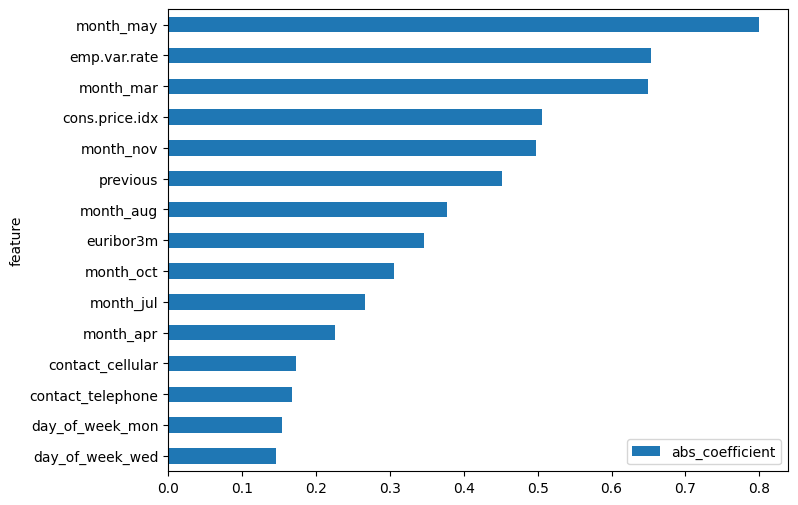

In [53]:
#Plot out the most important features

impt_features = coefficients.head(15).sort_values("abs_coefficient")

impt_features.plot.barh(x="feature", y="abs_coefficient", figsize=(8,6))